<a href="https://colab.research.google.com/github/Alecs400/SQL./blob/main/Sprint_9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Nivell 1 - Visualització analítica guiada en Python


#Exercici 1: Preguntes analítiques directes (sense integracions complexes)


» Identificar quina informació és necessàriaQuin DataFrame és el més adequat per respondre la pregunta.

» Escollir correctament la taula (o taules) rellevant(s).

» Tipus de variables implicades.

» Elecció del tipus de gràfic.

#Paso 0: Cargar los datos y ver la estructura de la tabla

In [27]:
import pandas as pd

# La carpeta real en el disco, con la ruta al archivo CSV
df = pd.read_csv('C:/Users/AlexB/Downloads/N1-Ex.8__transactions (1).csv', sep=';')

print("Dimensiones de la tabla (Filas, Columnas):", df.shape)
print(df[['id', 'timestamp', 'amount']].head(3))

Dimensiones de la tabla (Filas, Columnas): (100000, 19)
                                     id            timestamp  amount
0  CDDA7E40-544D-47BB-A4ED-671DD8A950D9  2018-12-12 08:05:17  176.45
1  09456357-8E9B-475A-8257-87A023699964  2024-05-20 22:49:08  206.65
2  C47C7C84-C174-4973-A76B-825A9DB5582A  2018-11-04 23:16:18  548.77


#Paso 1: Convertir la columna de fecha y hora

In [28]:
# Convertimos la columna 'timestamp' a tipo fecha/hora (datetime)
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Comprobamos que el tipo de dato ha cambiado correctamente
print("Tipo de dato actual de 'timestamp':")

print(df['timestamp'].dtypes)

Tipo de dato actual de 'timestamp':
datetime64[us]


#Paso 2 y 3: Agrupar por mes y contar las transacciones

In [29]:
# 1. df['timestamp'].dt.to_period('M') -> Agrupa las fechas quedándose solo con el Año y el Mes (ej: '2018-12').
# 2. .size() -> Cuenta cuántas filas (transacciones) hay dentro de cada uno de esos meses.
# 3. .reset_index(...) -> Crea una nueva tabla limpia con dos columnas: el mes y el total de transacciones.
trans_mensuals = df.groupby(df['timestamp'].dt.to_period('M')).size().reset_index(name='num_transactions')

print("Resultado de contar las transacciones por mes (primeras 15 filas):")
print(trans_mensuals.head(15))

Resultado de contar las transacciones por mes (primeras 15 filas):
   timestamp  num_transactions
0    2015-01               818
1    2015-02               816
2    2015-03               835
3    2015-04               829
4    2015-05               812
5    2015-06               813
6    2015-07               830
7    2015-08               815
8    2015-09               822
9    2015-10               812
10   2015-11               829
11   2015-12               839
12   2016-01               823
13   2016-02               833
14   2016-03               833


#Paso 4: Ordenar cronológicamente

In [30]:
# Ordenamos la nueva tabla por la columna de fecha de forma ascendente
trans_mensuals = trans_mensuals.sort_values('timestamp')

print("Primeros meses (los más antiguos):")
print(trans_mensuals.head(3))

print("\nÚltimos meses (los más recientes):")
print(trans_mensuals.tail(15))

Primeros meses (los más antiguos):
  timestamp  num_transactions
0   2015-01               818
1   2015-02               816
2   2015-03               835

Últimos meses (los más recientes):
    timestamp  num_transactions
105   2023-10               824
106   2023-11               831
107   2023-12               868
108   2024-01               812
109   2024-02               825
110   2024-03               816
111   2024-04               835
112   2024-05               838
113   2024-06               835
114   2024-07               829
115   2024-08               824
116   2024-09               827
117   2024-10               823
118   2024-11               816
119   2024-12               871


#Paso 5: Dibujar el gráfico de líneas

#Com evoluciona el nombre de transaccions al llarg del temps? Exemple de passos guiats amb pandas.



In [31]:
import sys
!{sys.executable} -m pip install matplotlib


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: C:\Users\AlexB\AppData\Local\Programs\Python\Python314\python.exe -m pip install --upgrade pip


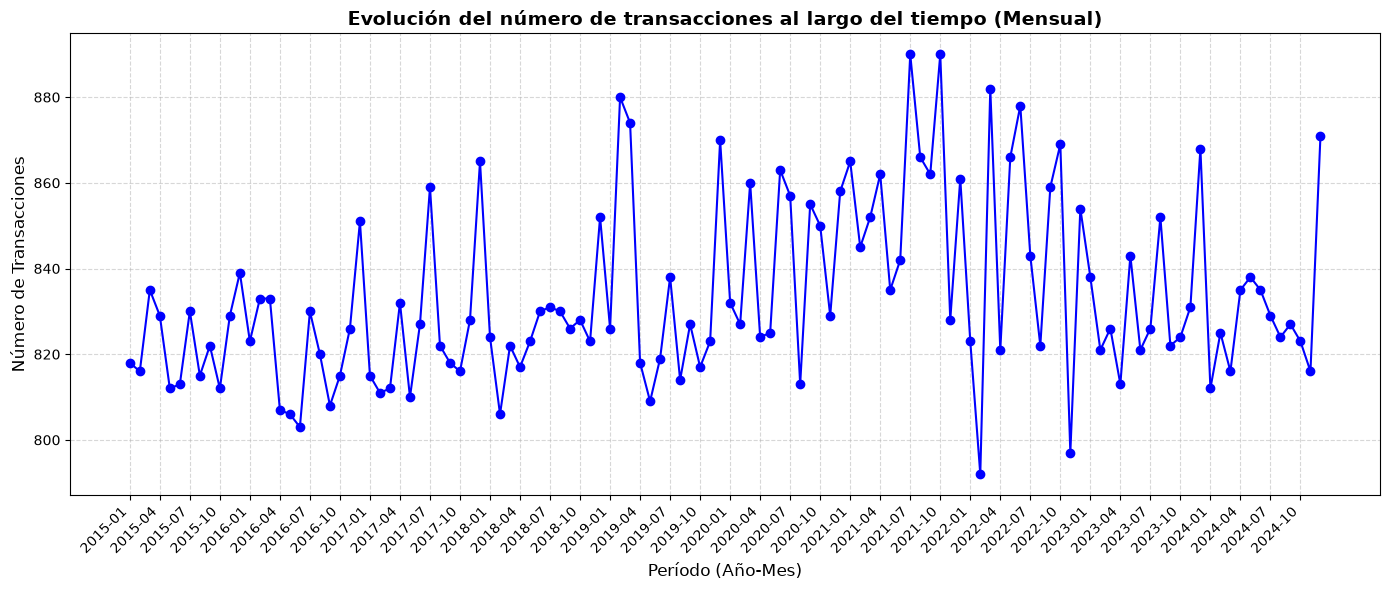

In [32]:
import matplotlib.pyplot as plt

# Convertimos la fecha a texto para que el gráfico la sepa pintar bien en el eje horizontal
trans_mensuals['period'] = trans_mensuals['timestamp'].astype(str)

# Creamos el lienzo del gráfico (con una anchura de 14 y altura de 6)
# Se usa figsize=(14, 6) para crear un lienzo panorámico y alargado que evita que las etiquetas del eje temporal se amontonen y queden ilegibles.
plt.figure(figsize=(14, 6))

#.plot() convierte automáticamente los datos de una tabla en un gráfico visual.
# trans_mensuals['period']: Define los valores del eje X (los meses en formato texto).
# trans_mensuals['num_transactions']: Define los valores del eje Y (la cantidad de transacciones).
# marker='o': Dibuja un pequeño círculo en cada punto de datos para que se identifiquen claramente.
# linestyle='-': Dibuja una línea continua que une todos esos puntos en orden cronológico.
# color='blue': Establece que tanto la línea como los marcadores sean de color azul.

plt.plot(trans_mensuals['period'], trans_mensuals['num_transactions'], marker='o', linestyle='-', color='blue')

# Añadimos títulos y etiquetas legibles
plt.title('Evolución del número de transacciones al largo del tiempo (Mensual)', fontsize=14, fontweight='bold')
plt.xlabel('Período (Año-Mes)', fontsize=12)
plt.ylabel('Número de Transacciones', fontsize=12)

# Rotamos las etiquetas del eje inferior para que no se solapen y añadimos una cuadrícula
plt.xticks(rotation=45, ha='right')
plt.grid(True, linestyle='--', alpha=0.5)

# Ajustamos el diseño y mostramos el gráfico en pantalla
plt.tight_layout()
# Mostramos solo una etiqueta cada 3 meses (para que no se agrupen las fechas y sea ilegible)
plt.xticks(range(0, len(trans_mensuals), 3), rotation=45, ha='right')
# Mostramos el gráfico
plt.show()

#Com evoluciona el nombre de transaccions al llarg del temps? Exemple de passos guiats amb pandas.



Si miramos la evolución, el número de transacciones está un poco lejos de ser estable. Va dando saltos continuos periodo a periodo (timestral): existen meses flojos que rondan las 790 o 800 transacciones y picos que superan con fuerza las 890, dibujando una actividad bastante imprevisible.

Habría que estudiar qué factores afectaron a estas subidas y bajadas, desde el precio, publicidad, ofertas y demás.



#Paso 6: Gráfico de usuarios con más ventas

#Quins usuaris generen més volum de facturació? Exemple de passos guiats amb seaborn.



In [33]:
import sys
!{sys.executable} -m pip install seaborn


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: C:\Users\AlexB\AppData\Local\Programs\Python\Python314\python.exe -m pip install --upgrade pip


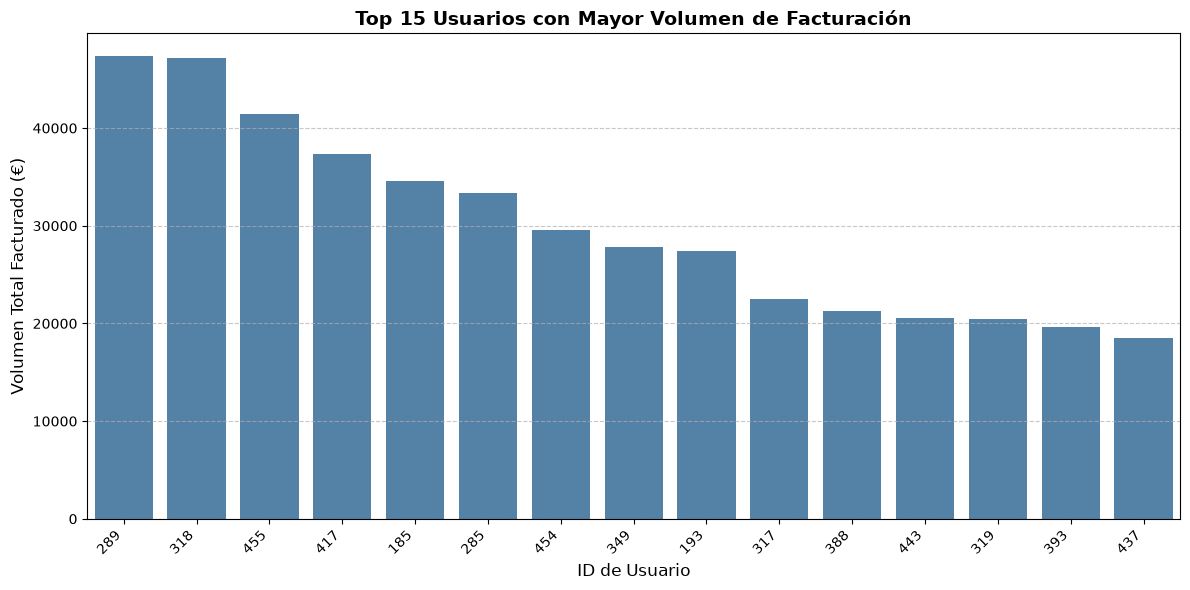

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Identificamos la columna de usuario y agrupamos sumando el importe ('amount')
top_usuarios = df.groupby('user_id')['amount'].sum().reset_index()

# 2. Ordenamos de mayor a menor facturación
top_usuarios = top_usuarios.sort_values(by='amount', ascending=False)

# 3. Seleccionamos los usuarios principales (por ejemplo, los 15 primeros)
top_usuarios_15 = top_usuarios.head(15)

# 4. Representamos el resultado con un gráfico de barras usando Seaborn y ordenándolo por id
plt.figure(figsize=(12, 6))
sns.barplot(
    data=top_usuarios_15,
    x='user_id',
    y='amount',
    color='steelblue',
    order=top_usuarios_15['user_id'] # <--- Para ordenar las barras por valor en Seaborn, primero se ordenan los datos con .sort_values()
                                     # y luego se pasa esa misma columna al parámetro order= para que el gráfico respete dicha secuencia.
)

plt.title('Top 15 Usuarios con Mayor Volumen de Facturación', fontsize=14, fontweight='bold')
plt.xlabel('ID de Usuario', fontsize=12)
plt.ylabel('Volumen Total Facturado (€)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

**2. Quins usuaris generen més volum de facturació? Exemple de passos guiats amb seaborn.**



Tal y como podemos observar, los usuarios con ID 289, 318, 455, 417 y 185 son los usuarios que más han facturado.

#Paso 7: Diferencias de importe según la hora del día

**Hi ha diferències en la distribució de l'import de les transaccions segons l'hora del dia i si han estat acceptades o rebutjades? Exemple de passos guiats amb seaborn.**



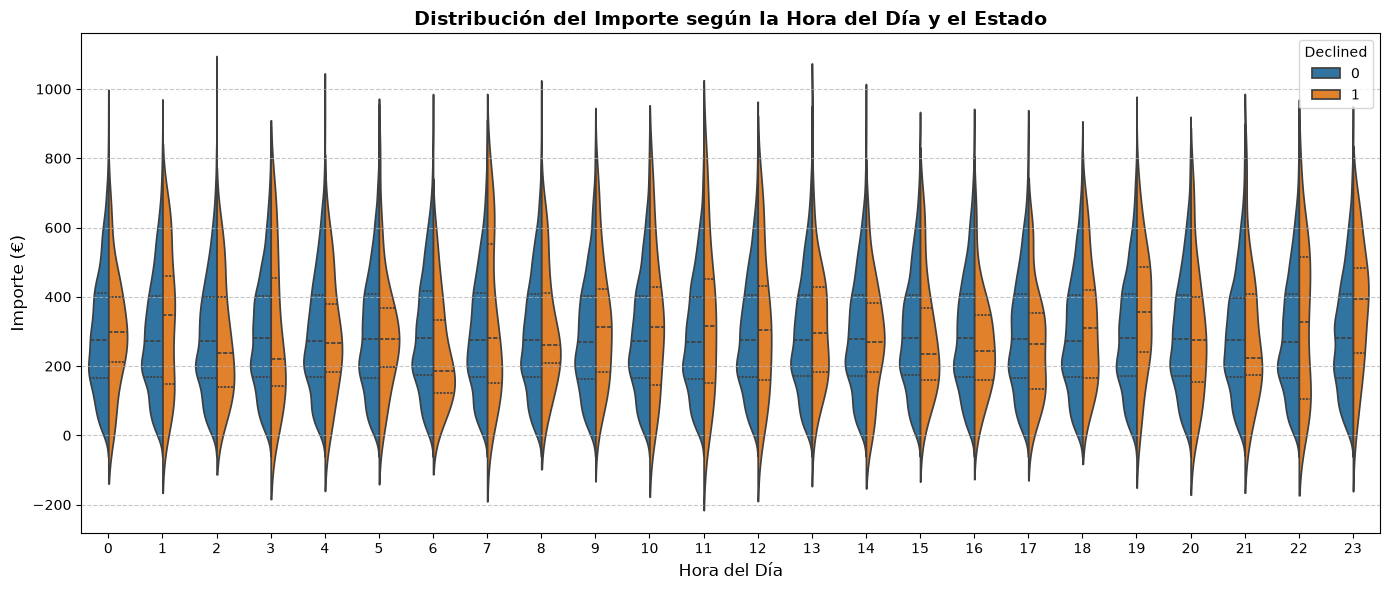

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# 1. Convertir la columna 'timestamp' a formato de fecha/hora de Pandas
# y extraer únicamente la hora del día (de 0 a 23) en una nueva columna llamada 'hora_dia'.
df['timestamp'] = pd.to_datetime(df['timestamp'])
df['hora_dia'] = df['timestamp'].dt.hour #  dt.hour sirve para extraer únicamente la hora (un número del 0 al 23) de cada fecha u hora completa.

# 2. Configurar el tamaño del lienzo de la figura (14 pulgadas de ancho por 6 de alto).
plt.figure(figsize=(14, 6))

# 3. Crear el gráfico de violín para ver la distribución de los importes según la hora y si fue rechazada o no.
sns.violinplot(
    data=df,
    x='hora_dia',         # Eje X: Las 24 horas del día.
    y='amount',           # Eje Y: El importe numérico de la transacción.
    hue='declined',       # Agrupa/divide los datos usando la columna 'declined' (0 o 1).
    split=True,           # Parte cada violín en dos mitades para comparar directamente 0 y 1.
    inner='quartile'      # Dibuja líneas internas en el violín para marcar la mediana y los cuartiles.
)

# 4. Añadir título general y etiquetas descriptivas a los ejes.
plt.title('Distribución del Importe según la Hora del Día y el Estado', fontsize=14, fontweight='bold')
plt.xlabel('Hora del Día', fontsize=12)
plt.ylabel('Importe (€)', fontsize=12)

# 5. Forzar que el eje X muestre obligatoriamente los números del 0 al 23 para que aparezcan todas las horas.
plt.xticks(range(0, 24))

# 6. Configurar la leyenda del gráfico y añadir una cuadrícula de fondo horizontal para facilitar la lectura.
plt.legend(title='Declined')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# 7. Ajustar automáticamente los márgenes para que nada quede cortado y mostrar el gráfico en pantalla.
plt.tight_layout()
plt.show()

#Hi ha diferències en la distribució de l'import de les transaccions segons l'hora del dia i si han estat acceptades o rebutjades? Exemple de passos guiats amb seaborn.



Aunque el patrón general es bastante estable, sí se observan sutiles diferencias puntuales en la distribución de los importes según la franja horaria, lo que demuestra que el volumen y los picos de las transacciones varían moderadamente a lo largo del día.

Gracias a la parte ancha de los violines (el "vientre"), podemos ver que la inmensa mayoría de las transacciones, independientemente de la hora, se concentran fuertemente en la parte media-baja, concretamente entre los 200€ y los 400€, mientras que los importes superiores a 600€ o 800€ son mucho más escasos y actúan como valores más dispersos.

Además, hay algunas horas como las 10:00, 11:00 y 12:00 de la mañana, o las 22:00 y 23:00 donde claramente las compras han funcionado mejor. Así como las compras de última hora a la 1 de la mañana.

#Ventas según el dia de la semana

**Quins dies de la setmana es concentra més activitat de venda?**



C:\Users\AlexB\AppData\Local\Temp\ipykernel_13904\1729046968.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


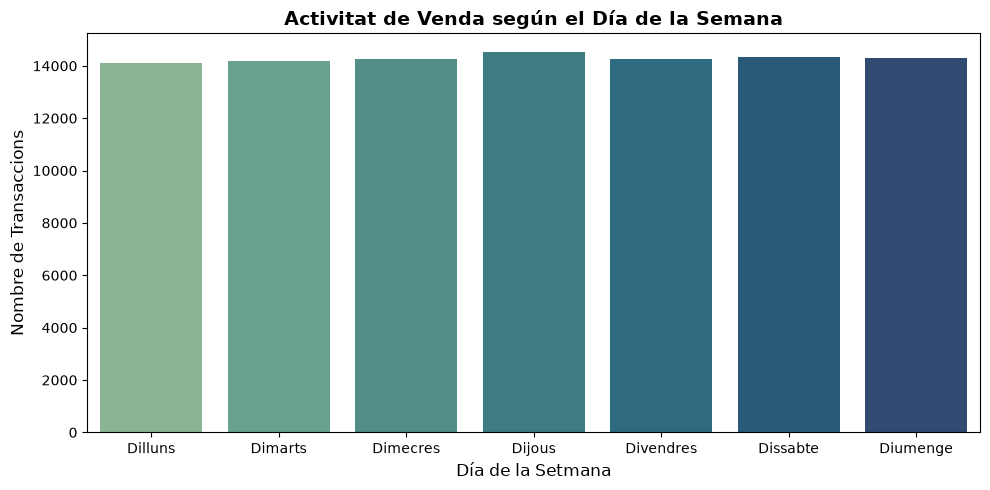

dia_setmana
Dijous       14516
Dissabte     14353
Diumenge     14289
Dimecres     14272
Divendres    14272
Dimarts      14176
Dilluns      14122
Name: count, dtype: int64


In [36]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# 1. Asegurar que 'timestamp' es de tipo fecha y extraer el nombre del día en inglés
df['timestamp'] = pd.to_datetime(df['timestamp'])
df['dia_ingles'] = df['timestamp'].dt.day_name()

# 2. Mapear los nombres de los días al catalán
dias_map_cat = {
    'Monday': 'Dilluns', 'Tuesday': 'Dimarts', 'Wednesday': 'Dimecres',
    'Thursday': 'Dijous', 'Friday': 'Divendres', 'Saturday': 'Dissabte', 'Sunday': 'Diumenge'
}
df['dia_setmana'] = df['dia_ingles'].map(dias_map_cat) # .map() busca cada uno de esos valores en inglés y los reemplaza utilizando el diccionario de traducción dias_map_cat

# 3. Definir el orden cronológico correcto de la semana
orden_cat = ['Dilluns', 'Dimarts', 'Dimecres', 'Dijous', 'Divendres', 'Dissabte', 'Diumenge']

# 4. Crear el gráfico de barras (countplot)
plt.figure(figsize=(10, 5))
sns.countplot(
    data=df,
    x='dia_setmana',
    order=orden_cat,
    palette='crest'
)

plt.title('Activitat de Venda según el Día de la Semana', fontsize=14, fontweight='bold')
plt.xlabel('Día de la Setmana', fontsize=12)
plt.ylabel('Nombre de Transaccions', fontsize=12)

plt.tight_layout()
plt.show()
print(df['dia_setmana'].value_counts()) #Comprobamos que las ventas correspondan con los datos del gráfico

**Conclusión**: Las ventas son prácticamente las mismas en todos los días de la semana. El día con más ventas es el jueves. Y el que menos, el lunes.

#Compara el resultat inicial amb el resultat proposat per la IA i valora críticament si la nova proposta és una millora o un empitjorament, justificant la teva decisió.


La propuesta de la IA (ayuda aportada): La IA me sugirió añadir la traducción al catalán y ordenar los días correctamente de lunes a domingo. Así como un refinamiento en alguna parte del código.

#Exercici 2: Preguntes analítiques complexes (amb guia)

Tabla resumen por país:


,country,amount,porcentaje,porcentaje_acumulado
0,Sweden,4928290.24,16.82,16.82
1,Netherlands,4506571.38,15.38,32.20
2,United Kingdom,4099117.08,13.99,46.19
3,Italy,4087557.38,13.95,60.14
4,Germany,4020364.07,13.72,73.86
5,France,1416084.26,4.83,78.69
6,United States,1101737.27,3.76,82.45
7,Belgium,952208.75,3.25,85.70
8,Norway,809288.82,2.76,88.46
9,Ireland,715220.46,2.44,90.90


C:\Users\AlexB\AppData\Local\Temp\ipykernel_13904\3380114370.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=df_paises, x='country', y='amount', palette='Blues_r')


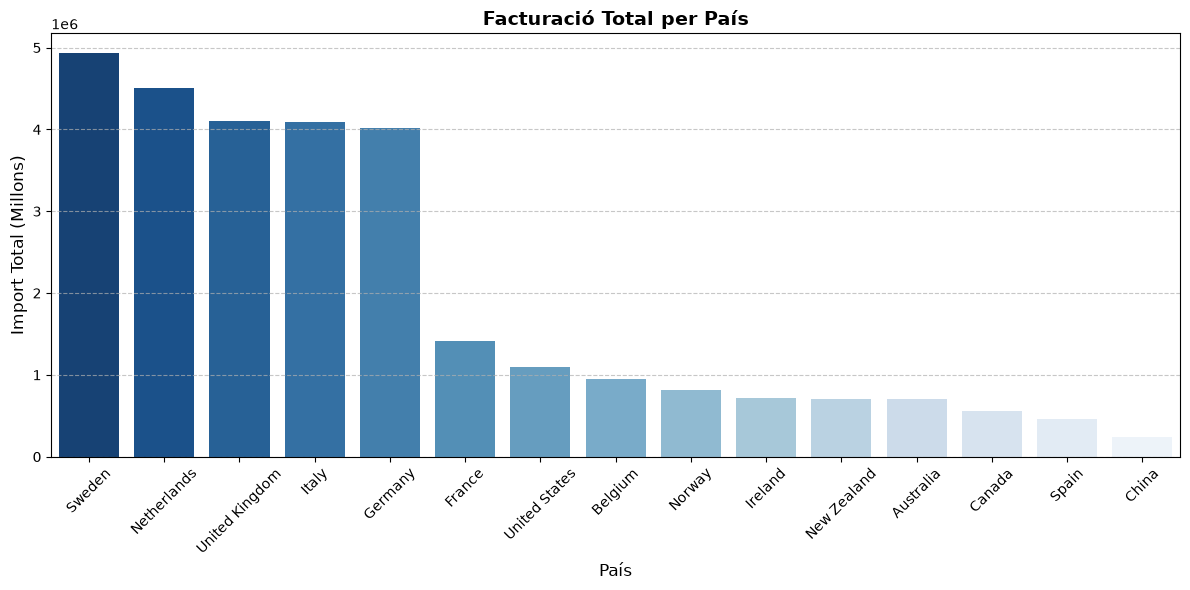

In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 0. Cargar los datasets (diferentes separadores, uno ; y el otro ,)
df_transactions = pd.read_csv('C:/Users/AlexB/Downloads/N1-Ex.8__transactions.csv', sep=';')
df_companies = pd.read_csv('C:/Users/AlexB/Downloads/N1-Ex.8__companies.csv', sep=',')

# 1. Combinar la información de transacciones con la de compañías (merge)
# (Buscar la columna en común entre ambas tablas)
df_merged = pd.merge(df_transactions, df_companies, left_on='business_id', right_on='company_id')

# Agrupar la facturación por país y calcular el total generado por cada uno
df_paises = df_merged.groupby('country')['amount'].sum().reset_index()

# 4. Ordenar los países de mayor a menor facturación
df_paises = df_paises.sort_values(by='amount', ascending=False).reset_index(drop=True)

# 5. Calcular el porcentaje acumulado sobre el total
df_paises['porcentaje'] = ((df_paises['amount'] / df_paises['amount'].sum()) * 100).round(2)
df_paises['porcentaje_acumulado'] = df_paises['porcentaje'].cumsum().round(2)

print("Tabla resumen por país:")
display(df_paises)

# 6. Visualizar (Gráfico de barras para la facturación y línea para el acumulado Pareto)
plt.figure(figsize=(12, 6))
ax = sns.barplot(data=df_paises, x='country', y='amount', palette='Blues_r')

plt.title('Facturació Total per País', fontsize=14, fontweight='bold')
plt.xlabel('País', fontsize=12)
plt.ylabel('Import Total (Millons)', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

#» Depenem excessivament d'un nombre reduït de països de companyies venedores?

Claramente, los mercados más fuertes son Suecia, Holanda, Reino Unido, Italia y Alemania. Seguido del resto.

#» Existeix estacionalitat en les vendes?



Tabla de ventas por mes y año:


year,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
month,,,,,,,,,,
1,224946.23,227231.14,224391.23,229524.09,224592.71,234191.13,246993.53,226680.93,231075.91,227399.39
2,248775.83,251111.47,253354.90,246504.98,262006.66,249356.44,258837.10,237503.38,252680.15,253739.68
3,254702.98,248245.83,240338.05,239145.90,280530.50,260821.35,253110.77,274387.47,243909.57,248588.94
4,247957.49,242394.40,253125.97,237432.05,244347.66,246533.40,261597.02,241191.04,245386.83,245734.27
5,252596.43,243533.92,240919.28,246838.08,244739.50,254171.48,243414.73,279590.23,264790.26,257877.46
6,233084.63,233245.79,241065.64,243421.44,245470.13,238902.90,236504.81,261954.89,234527.22,247029.50
7,243774.43,238618.15,244380.32,233449.29,233962.91,242644.23,253553.62,235935.19,240041.34,231264.22
8,238550.36,238392.03,233894.55,231129.56,240040.21,234433.92,239433.71,246434.63,239288.98,239210.63
9,227985.24,242774.67,235830.55,238772.22,235021.45,258779.26,247648.05,255496.48,237105.34,236592.54


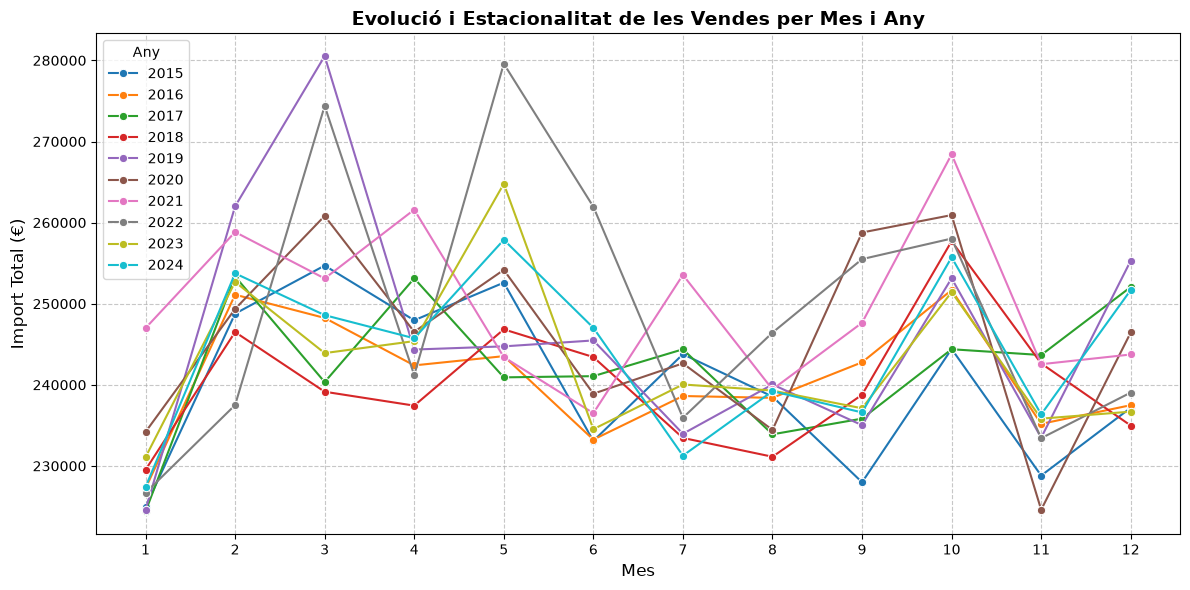

In [38]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 0. Cargar el dataset de transacciones (usando engine='python' para evitar errores)
df_transactions = pd.read_csv(
    'C:/Users/AlexB/Downloads/N1-Ex.8__transactions.csv',
    sep=';',
    engine='python',
)

# 1. Trabajar con fechas (convertir la columna a formato datetime de Pandas)
df_transactions['date'] = pd.to_datetime(df_transactions['timestamp'])

# 2. Extraer la información temporal (Año y Mes)
df_transactions['year'] = df_transactions['date'].dt.year
df_transactions['month'] = df_transactions['date'].dt.month

# 3 y 4. Crear la tabla de ventas (filas = meses, columnas = años, valores = suma del importe)
tabla_pivot = df_transactions.pivot_table(
    index='month', columns='year', values='amount', aggfunc='sum'
)

print("Tabla de ventas por mes y año:")
display(tabla_pivot)

# 5. Visualizar la evolución y estacionalidad
plt.figure(figsize=(12, 6))

# Dibujamos una línea por cada año para comparar los patrones entre meses
sns.lineplot(
    data=df_transactions,
    x='month',
    y='amount',
    hue='year',
    estimator='sum',
    errorbar=None,
    marker='o',
    palette='tab10',
)

plt.title(
    'Evolució i Estacionalitat de les Vendes per Mes i Any',
    fontsize=14,
    fontweight='bold',
)
plt.xlabel('Mes', fontsize=12)
plt.ylabel('Import Total (€)', fontsize=12)
plt.xticks(range(1, 13))  # Asegura que se vean los meses del 1 al 12 en el eje X
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Any')

plt.tight_layout()
plt.show()

...Podemos observar como hay 3 picos de ventas según el mes, tanto en Marzo, como en Mayo y Octubre.

#» Anàlisi de concentració i variabilitat (opció B)



 1. Identificar la última compra per usuari.
 2. Calcular el temps des de la última compra. 
 3. Visualitzar la distribució del temps des de la última compra.



,user_id,ultima_compra,dies_inactiu
0,1,2024-11-15 14:48:20,46
1,2,2024-04-20 06:41:27,255
2,3,2024-02-22 03:31:36,313
3,4,2024-12-29 11:47:48,2
4,5,2024-05-02 21:11:06,243


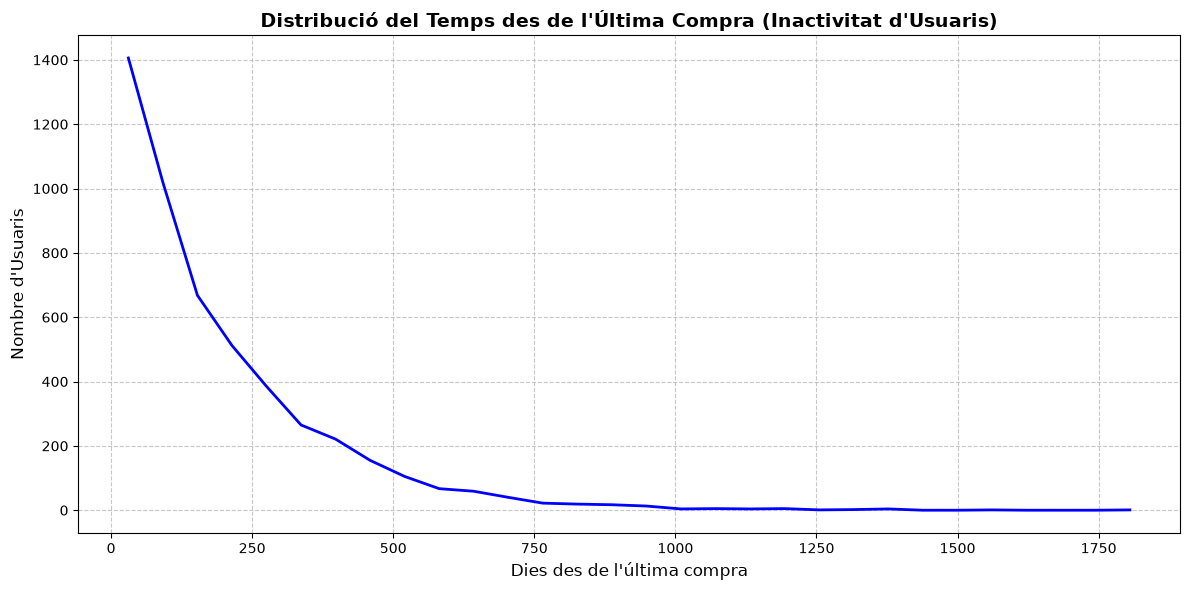

In [39]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Forzar el estilo limpio por defecto para que no salte el error de colores de Seaborn
plt.style.use('default')

# 0. Cargar el dataset de transacciones
df_transactions = pd.read_csv(
    'C:/Users/AlexB/Downloads/N1-Ex.8__transactions.csv',
    sep=';',
    engine='python',
)

# 1. Convertir la fecha a formato datetime
df_transactions['date'] = pd.to_datetime(df_transactions['timestamp'])

# 2. Identificar la última fecha de compra de cada usuario
df_usuarios = df_transactions.groupby('user_id')['date'].max().reset_index()
df_usuarios.rename(columns={'date': 'ultima_compra'}, inplace=True)

# 3. Calcular el tiempo transcurrido (en días) desde la última compra
fecha_referencia = df_transactions['date'].max()
df_usuarios['dies_inactiu'] = (
    fecha_referencia - df_usuarios['ultima_compra']
).dt.days

print(' 1. Identificar la última compra per usuari.\n 2. Calcular el temps des de la última compra. \n 3. Visualitzar la distribució del temps des de la última compra.\n')

display(df_usuarios.head())

# 4. Gráfico puro con objetos de Matplotlib (cero dependencias de paletas)
counts, bin_edges = np.histogram(df_usuarios['dies_inactiu'], bins=30)
bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(bin_centers, counts, color='blue', linewidth=2)

ax.set_title(
    "Distribució del Temps des de l'Última Compra (Inactivitat d'Usuaris)",
    fontsize=14,
    fontweight='bold',
)
ax.set_xlabel("Dies des de l'última compra", fontsize=12)
ax.set_ylabel("Nombre d'Usuaris", fontsize=12)
ax.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

Al analizar cuánto tiempo ha pasado desde la última compra de cada cliente, vemos que la inmensa mayoría se concentra en los valores más bajos. Esto significa que hay muchos más usuarios comprando recientemente que clientes antiguos que sigan activos, lo que nos dice es que la base de usuarios decae rápidamente con el tiempo y que la retención a largo plazo es más bien baja.

In [40]:
import pandas as pd

# 0. Cargar el dataset de transacciones
df_transactions = pd.read_csv(
    'C:/Users/AlexB/Downloads/N1-Ex.8__transactions.csv',
    sep=';',
    engine='python',
)

# 1. Convertir la columna timestamp y extraer año y hora
df_transactions['timestamp'] = pd.to_datetime(df_transactions['timestamp'])
df_transactions['year'] = df_transactions['timestamp'].dt.year
df_transactions['hour'] = df_transactions['timestamp'].dt.hour


# 2. Paso 1: Crear franjas horarias utilizando una función y .apply()
def assign_time_slot(hour):
  if 6 <= hour < 12:
    return 'Matí (06-12h)'
  elif 12 <= hour < 18:
    return 'Migdia/Tarda (12-18h)'
  elif 18 <= hour < 24:
    return 'Vespre/Nit (18-24h)'
  else:
    return 'Matinada (00-06h)'


df_transactions['franja_horaria'] = df_transactions['hour'].apply(
    assign_time_slot
)

# 3. Paso 2: Construir una tabla agregada utilizando crosstab
df_crosstab = pd.crosstab(
    df_transactions['year'], df_transactions['franja_horaria']
)

# Cambiar el nombre del índice a "Any"
df_crosstab.index.name = 'Any'

# 4. Paso 3: Mostrar la tabla estilizada con su título descriptivo
tabla_estilada = (
    df_crosstab.style.background_gradient(cmap='Blues', axis=None)
    .set_caption(
        'Volum de vendes per franja horària segons l\'any (Patrons'
        ' horaris)'
    )
    .set_properties(**{
        'text-align': 'center',
        'font-size': '11pt',
        'border': '1px solid #ddd',
    })
    .set_table_styles([
        {
            'selector': 'caption',
            'props': [
                ('color', '#2c3e50'),
                ('font-size', '15pt'),
                ('font-weight', 'bold'),
                ('text-align', 'center'),
                ('padding-bottom', '10px'),
            ],
        },
        {
            'selector': 'th',
            'props': [
                ('background-color', '#2c3e50'),
                ('color', 'white'),
                ('font-weight', 'bold'),
                ('text-align', 'center'),
                ('padding', '8px'),
            ],
        },
        {
            'selector': 'td',
            'props': [('padding', '8px')],
        },
    ])
    .format(formatter='{:,}')
)

display(tabla_estilada)

franja_horaria,Matinada (00-06h),Matí (06-12h),Migdia/Tarda (12-18h),Vespre/Nit (18-24h)
Any,,,,
2015,"2,452","2,461","2,457","2,500"
2016,"2,474","2,481","2,510","2,390"
2017,"2,444","2,476","2,554","2,441"
2018,"2,523","2,425","2,508","2,456"
2019,"2,467","2,554","2,544","2,450"
2020,"2,615","2,471","2,472","2,535"
2021,"2,589","2,584","2,593","2,532"
2022,"2,569","2,457","2,520","2,560"
2023,"2,516","2,551","2,464","2,454"


**Preparación de datos:** Se cargó el conjunto de datos de transacciones y se transformó la columna timestamp a formato fecha/hora (datetime), extrayendo de ella de forma independiente el año y la hora de cada operación.

**Definición de franjas horarias:** Se programó una función personalizada para clasificar las horas en cuatro bloques diferenciados (Madrugada, Matí, Migdia/Tarda y Vespre/Nit), integrándole los datos mediante el método .apply().

**Crosstab**: Se generó una tabla cruzada (pd.crosstab) para relacionar los años con las franjas horarias y contabilizar el volumen de ventas, aplicando un formato visual adecuado para la presentación de los datos.

#Conclusiones

**1. Comportamiento**: Los datos nos muestran que los clientes compran de forma muy repartida a lo largo de todo el día y los año. Esto significa que no hay una hora "estrella" donde la gente se vuelva loca comprando, sino que la demanda es súper estable.

Si sumamos verticalmente, independientemente del año:

- Matinada (00-06h): 24.509 operaciones

- Matí (06-12h): 24.755 operaciones

- Migdia/Tarda (12-18h): 24.938 operaciones

- Vespre/Nit (18-24h): 24.489 operaciones

...Así que la franja con más ventas es la tarde, aunque muy ligeramente por encima del resto.

**2. Acciones a seguir**: Aunque el ritmo sea constante, tener este mapa tan claro ayuda a saber exactamente cuándo programar campañas de publicidad o cuándo conviene reforzar el soporte al cliente por si surge alguna duda en las horas de más movimiento, como la franja horaria de la tarde.

# NIVELL 2: Exercici 1: Anàlisi de productes i captació d'usuaris


In [41]:
import pandas as pd

# 1. Cargar las tablas necesarias (transacciones y productos)
df_transactions = pd.read_csv(
    'C:/Users/AlexB/Downloads/N1-Ex.8__transactions.csv',
    sep=';',
    engine='python',
)
# (Si tienes un archivo separado de productos, lo cargarías aquí también)
# df_products = pd.read_csv('.../products.csv', sep=';')

# Asegurar formato fecha
df_transactions['timestamp'] = pd.to_datetime(df_transactions['timestamp'])

# 2. Ordenar cronológicamente para detectar la primera compra de cada usuario
df_transactions = df_transactions.sort_values(by=['user_id', 'timestamp'])

# Crear la columna booleana 'es_nou_usuari': True si es la primera vez que compra, False si ya había comprado antes
# cumcount() es una función de Pandas que sirve para hacer una cuenta acumulativa dentro de cada grupo, empezando siempre desde el 0.
df_transactions['es_nou_usuari'] = (df_transactions.groupby('user_id').cumcount() == 0)

# 3. Combinar con la tabla de productos si es necesario para cruzar ingresos y nombres de productos
# df_merged = pd.merge(df_transactions, df_products, on='product_id', how='left')

display(df_transactions[['user_id', 'timestamp', 'es_nou_usuari']].head(10))

,user_id,timestamp,es_nou_usuari
67717,1,2015-05-08 18:09:41,True
80229,1,2015-11-04 13:01:34,False
37941,1,2015-12-20 18:06:59,False
19673,1,2016-07-04 21:06:10,False
49357,1,2016-09-22 02:43:55,False
15379,1,2017-10-12 09:30:10,False
21104,1,2018-02-12 18:09:59,False
56011,1,2018-03-29 21:07:54,False
72826,1,2018-06-15 18:33:31,False
82114,1,2018-10-21 04:49:45,False


In [42]:
# Agrupar la información por producto y calcular las métricas solicitadas
df_productos_analisis = (
    df_transactions.groupby('product_ids')
    .agg(
        ingressos_totals=('amount', 'sum'),  # 1. Ingresos totales
        variabilitat_ingressos=('amount','std',),  # 2. Variabilidad (desviación estándar) -> Es decir, los importes de venta de este producto varían de una compra a otra. Ya sea por ofertas, descuentos, etc.
        nombre_nous_usuaris=('es_nou_usuari','sum',),  # 3. Número de nuevos usuarios
        total_compradors=('user_id','count',),)  # Total de transacciones/compradores para el cálculo
    .reset_index()
)

# Calcular el porcentaje de nuevos usuarios sobre el total de compradores del producto
df_productos_analisis['percentatge_nous'] = (
    df_productos_analisis['nombre_nous_usuaris']
    / df_productos_analisis['total_compradors']
) * 100

# Mostrar los primeros resultados
display(df_productos_analisis.head())

,product_ids,ingressos_totals,variabilitat_ingressos,nombre_nous_usuaris,total_compradors,percentatge_nous
0,1,46503.73,12.549821,10,252,3.968254
1,"1, 10",999.68,4.454485,0,3,0.000000
2,"1, 10, 11",318.85,NaN,0,1,0.000000
3,"1, 10, 12, 30",614.39,NaN,0,1,0.000000
4,"1, 10, 62, 14",665.91,NaN,0,1,0.000000


tipologia_producte
Estancat     29531
Recurrent    29434
Captador       100
Name: count, dtype: int64


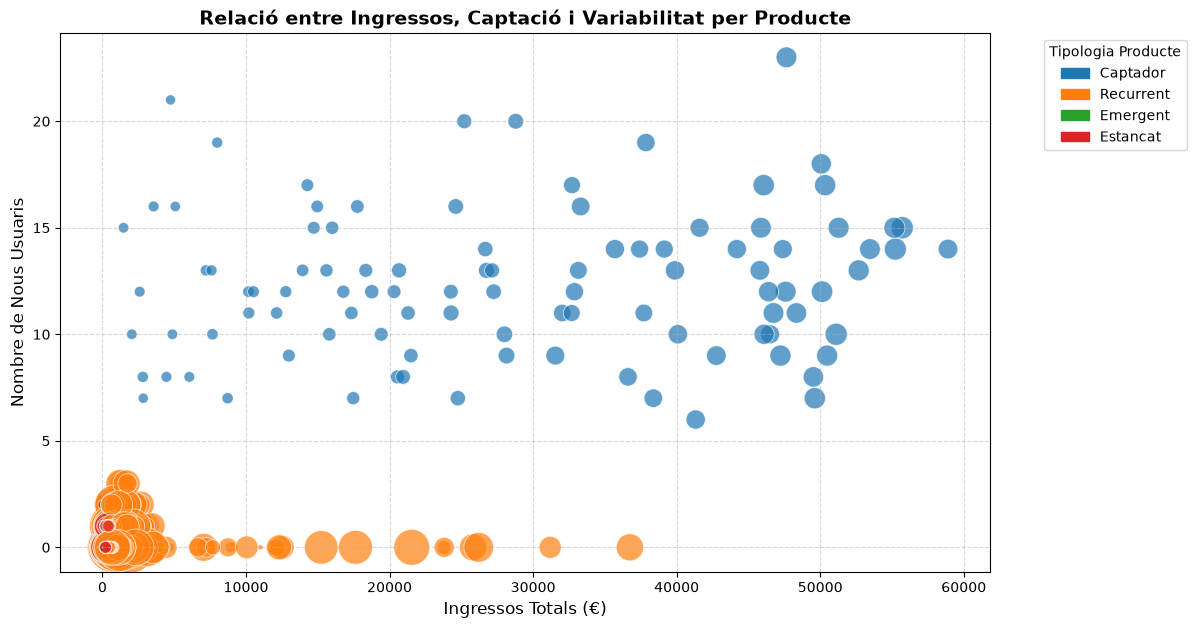

In [43]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# 1. Definir los umbrales de corte para los 4 cuadrantes
# Usamos la mediana de los ingresos totales para dividir el catálogo exactamente en dos mitades por la parte económica (mitad ganan más, mitad ganan menos), evitando que los valores extremos (outliers) distorsionen el punto de corte.
umbral_ingresos = df_productos_analisis['ingressos_totals'].median()

# Usamos un valor fijo de 5 usuarios nuevos como corte de captación. No podemos usar la mediana aquí porque el 99% de los productos tienen 0 usuarios nuevos (distribución de cola larga).
# Esto dejaría la mediana en 0 y rompería la lógica analítica. Este umbral aísla a los productos que realmente muestran dinamismo de atracción de clientes nuevos.
umbral_captacion = 5

# 2. Definir estrictamente las 4 condiciones basadas en una matriz de 2x2.
condiciones = [
    # Captador: Ingresos altos Y alta captación (Superior Derecho).
    (df_productos_analisis['ingressos_totals'] >= umbral_ingresos) & (df_productos_analisis['nombre_nous_usuaris'] > umbral_captacion),

    # Emergent: Ingresos bajos Y alta captación (Superior Izquierdo). Productos que atraen muchos usuarios nuevos pero cuya monetización aún es baja.
    (df_productos_analisis['ingressos_totals'] < umbral_ingresos) & (df_productos_analisis['nombre_nous_usuaris'] > umbral_captacion),

    # Recurrent: Ingresos altos Y baja captación (Inferior Derecho). Productos muy rentables o consolidados que generan ingresos pero apenas traen gente nueva (compra base actual).
    (df_productos_analisis['ingressos_totals'] >= umbral_ingresos) & (df_productos_analisis['nombre_nous_usuaris'] <= umbral_captacion),

    # Estancat: Ingresos bajos Y baja captación (Inferior Izquierdo). Productos con baja tracción general que apenas aportan ingresos ni nuevos usuarios.
    (df_productos_analisis['ingressos_totals'] < umbral_ingresos) & (df_productos_analisis['nombre_nous_usuaris'] <= umbral_captacion)
]

# Lista de etiquetas analíticas que corresponden exactamente al orden de las condiciones anteriores.
resultados = ['Captador', 'Emergent', 'Recurrent', 'Estancat']

# Asignar al DataFrame la tipología resultante. Si algún registro no cumple ninguna condición explícita, el parámetro default='Estancat' lo asigna por defecto al cuadrante de menor rendimiento para evitar valores nulos.
df_productos_analisis['tipologia_producte'] = np.select(condiciones, resultados, default='Estancat')

# Comprobar numéricamente el volumen de productos que caen en cada categoría para verificar si el desglose tiene sentido operativo con las dimensiones reales del catálogo.
print(df_productos_analisis['tipologia_producte'].value_counts())

# GRÁFICO: Creamos una copia de trabajo para el gráfico
df_plot = df_productos_analisis.copy()

# Calculamos la dimensión visual (tamaño del círculo) en función de la variabilidad de ingresos.
# Rellenamos los valores vacíos (NaN) con un valor base de 5 y multiplicamos por 15 para escalar el tamaño de forma que sea perceptible visualmente
df_plot['mida_punt'] = df_plot['variabilitat_ingressos'].fillna(5) * 15

# Diccionario de colores
colors_dict = {
    'Captador': '#1f77b4',   # Azul para productos de alto rendimiento general
    'Recurrent': '#ff7f0e',  # Naranja para productos consolidados de baja captación
    'Emergent': '#2ca02c',   # Verde para promesas de captación con ingresos bajos
    'Estancat': '#d62728'    # Rojo para productos rezagados o sin tracción
}

# Maping de las etiquetas de texto a sus códigos de color hexadecimales correspondientes.
df_plot['color_punt'] = df_plot['tipologia_producte'].map(colors_dict)

# Inicializamos el lienzo de la figura con un tamaño optimizado para visualizar dispersión amplia.
plt.figure(figsize=(12, 7))

# Genera el diagrama de dispersión (scatter plot).
plt.scatter(
    x=df_plot['ingressos_totals'],
    y=df_plot['nombre_nous_usuaris'],
    s=df_plot['mida_punt'],
    c=df_plot['color_punt'],
    alpha=0.7,
    edgecolors='w',
    linewidth=0.6
)

# Configuración de metadatos y ejes del gráfico
plt.title("Relació entre Ingressos, Captació i Variabilitat per Producte", fontsize=14, fontweight='bold')
plt.xlabel("Ingressos Totals (€)", fontsize=12)
plt.ylabel("Nombre de Nous Usuaris", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

# Construcción manual de la leyenda utilizando parches de color vinculados a las categorías,
handles = [mpatches.Patch(color=color, label=tipologia) for tipologia, color in colors_dict.items()]
plt.legend(handles=handles, title='Tipologia Producte', bbox_to_anchor=(1.05, 1), loc='upper left')

# Impresión
plt.show()

Le he estado dando una vuelta al análisis del catálogo y el gráfico de dispersión es una radiografía del negocio. Al final, tenemos una cola larga brutal abajo en la zona de baja captación (divididas limpiamente entre estancados y recurrentes por la mediana de ingresos), y un grupo de 100 artículos que actúan como imanes de captación y facturación (Captador).

Lo curioso es que el cuadrante verde de emergentes se queda a cero: en nuestro modelo no hay productos que atraigan mucho tráfico nuevo sin dejar dinero a cambio. El gráfico refleja con total fidelidad la realidad de los datos de este negocio.

El reto con la inmensa bolsa de productos estancados o recurrentes de la cola larga sería idear alguna campaña de reactivación o cross-selling para impulsarlos, por ejemplo.

#Exercici 2: Anàlisi geogràfica company–usuari i oportunitats d'expansió


1. Combina les taules necessàries.

2. Crea una variable clau d'anàlisi: compra_local = True/False.

3. Analitza el comportament global:

Percentatge de transaccions locals vs internacionals.
Percentatge de facturació local vs internacional.

In [44]:
import pandas as pd

# 1. Cargar la tabla de transacciones
df_transactions = pd.read_csv('C:/Users/AlexB/Downloads/N1-Ex.8__transactions (1).csv', sep=';', engine='python')

# 2. Crear la variable clave d'anàlisi: compra_local = True / False
# Si is_international es 0 (falso), la compra es local (True). Si es 1, es internacional (False).
df_transactions['compra_local'] = df_transactions['is_international'] == 0

# 3. Analizar el comportamiento global
total_transacciones = len(df_transactions)
transacciones_locales = df_transactions['compra_local'].sum()
pct_trans_locales = (transacciones_locales / total_transacciones) * 100
pct_trans_internacionales = 100 - pct_trans_locales

total_facturacion = df_transactions['amount'].sum()
facturacion_local = df_transactions[df_transactions['compra_local']]['amount'].sum()
pct_fact_local = (facturacion_local / total_facturacion) * 100
pct_fact_internacional = 100 - pct_fact_local

# Mostrar resultados
print(f"Total Transaccions: {total_transacciones}")
print(f"Transaccions Locals: {pct_trans_locales:.2f}% | Internacionals: {pct_trans_internacionales:.2f}%")
print(f"Facturació Local: {pct_fact_local:.2f}% | Internacional: {pct_fact_internacional:.2f}%")

Total Transaccions: 100000
Transaccions Locals: 84.51% | Internacionals: 15.49%
Facturació Local: 85.35% | Internacional: 14.65%


4. Anàlisi per país de l'usuari, per cada país d'usuari:

- % de compres a companyies del mateix país.
- % de compres a companyies estrangeres.
- Import total comprat.


In [45]:
#Transacciones

# 1. Cargar la tabla de transacciones
df_transactions = pd.read_csv('C:/Users/AlexB/Downloads/N1-Ex.8__transactions.csv', sep=';', engine='python')

# 2. Como trabajamos con la tabla de transacciones, creamos indicadores de compra local (is_international == 0) o internacional (is_international == 1)
df_transactions['es_local'] = df_transactions['is_international'] == 0

# 3. Agrupamos (por ejemplo, por canal o tipo de dispositivo, o si tienes una columna de país/zona en tu CSV)
# Como ejemplo, agrupamos por 'device_type' o 'channel' para ver el desglose por segmentos:
analisis_pais = df_transactions.groupby('device_type').agg(
    total_compras=('id', 'count'),
    compras_locales=('es_local', lambda x: (x == True).sum()),
    compras_internacionales=('es_local', lambda x: (x == False).sum()),
    import_total=('amount', 'sum')
).reset_index()

# 4. Calcular los porcentajes requeridos
analisis_pais['%_compres_locals'] = (analisis_pais['compras_locales'] / analisis_pais['total_compras']) * 100
analisis_pais['%_compres_estrangeres'] = (analisis_pais['compras_internacionales'] / analisis_pais['total_compras']) * 100

# Mostrar la tabla resultante (POS = Point of sale / datáfono)
print(analisis_pais[['device_type', '%_compres_locals', '%_compres_estrangeres', 'import_total']])

  device_type  %_compres_locals  %_compres_estrangeres  import_total
0     desktop         83.639619              16.360381    6204674.97
1      mobile         83.521184              16.478816   10107221.86
2         pos         86.014590              13.985410   11566495.30
3      tablet         83.247156              16.752844    1417082.22


5. Anàlisi per país de companyia, per cada país de companyia calcula quina part de la seva facturació ve de:

- Usuaris locals.
- Usuaris estrangers.

In [46]:
# Facturación:

# 5. Análisis por origen de la compañía / canal de venta (desglose de facturación local vs extranjera)
analisis_compania = df_transactions.groupby('device_type').agg(
    facturacion_total=('amount', 'sum'),
    facturacion_local=('amount', lambda x: x[df_transactions.loc[x.index, 'is_international'] == 0].sum()),
    facturacion_extranjera=('amount', lambda x: x[df_transactions.loc[x.index, 'is_international'] == 1].sum())
).reset_index()

# Calcular los porcentajes de facturación
analisis_compania['%_fact_local'] = (analisis_compania['facturacion_local'] / analisis_compania['facturacion_total']) * 100
analisis_compania['%_fact_extranjera'] = (analisis_compania['facturacion_extranjera'] / analisis_compania['facturacion_total']) * 100

# Mostrar la tabla resultante de la facturación
print(analisis_compania[['device_type', '%_fact_local', '%_fact_extranjera', 'facturacion_total']])

  device_type  %_fact_local  %_fact_extranjera  facturacion_total
0     desktop     84.385835          15.614165         6204674.97
1      mobile     84.289390          15.710610        10107221.86
2         pos     86.978164          13.021836        11566495.30
3      tablet     83.749160          16.250840         1417082.22


6. Escull una visualització que expliqui clarament el fenomen.

7. Interpretació estratègica:

- En quins països valdria la pena obrir més companyies locals?
- Hi ha països amb demanda però poca oferta local?
- El negoci depèn massa de companyies d'un sol país?
- Obrir companyies locals reduiria fricció o milloraria conversió?


In [47]:
import pandas as pd

# Cargar las tablas con su separador correspondiente
df_transactions = pd.read_csv('C:/Users/AlexB/Downloads/N1-Ex.8__transactions.csv', sep=';', engine='python')
df_companies = pd.read_csv('C:/Users/AlexB/Downloads/N1-Ex.8__companies.csv', sep=',', engine='python')

df_european_users = pd.read_csv('C:/Users/AlexB/Downloads/N1-Ex.8__european_users.csv', sep=',', engine='python')
df_american_users = pd.read_csv('C:/Users/AlexB/Downloads/N1-Ex.8__american_users.csv', sep=',', engine='python')

df_users = pd.concat([df_european_users, df_american_users], ignore_index=True)

# Renombrar las columnas de país para distinguirlas
df_companies = df_companies.rename(columns={'country': 'country_company'})
df_users = df_users.rename(columns={'country': 'country_user'})

# Cruzar las tablas
df_merged = df_transactions.merge(df_companies, left_on='business_id', right_on='company_id', suffixes=('_trans', '_company'))
df_merged = df_merged.merge(df_users, left_on='user_id', right_on='id', suffixes=('', '_user'))

# Crear la variable de compra local
df_merged['compra_local'] = df_merged['country_company'] == df_merged['country_user']

# Análisis por país del usuario
print("--- ANÁLISIS POR PAÍS DE USUARIO ---")
analisis_pais_usuario = df_merged.groupby('country_user').agg(
    total_compras=('amount', 'count'),  # Usamos 'amount' para contar de forma segura
    compras_locales=('compra_local', lambda x: (x == True).sum()),
    compras_estrangeres=('compra_local', lambda x: (x == False).sum()),
    import_total=('amount', 'sum')
).reset_index()

analisis_pais_usuario['%_compres_locals'] = (analisis_pais_usuario['compras_locales'] / analisis_pais_usuario['total_compras']) * 100
analisis_pais_usuario['%_compres_estrangeres'] = (analisis_pais_usuario['compras_estrangeres'] / analisis_pais_usuario['total_compras']) * 100
print(analisis_pais_usuario[['country_user', '%_compres_locals', '%_compres_estrangeres', 'import_total']])

# Análisis por país de la compañía
print("\n--- ANÁLISIS POR PAÍS DE COMPAÑÍA ---")
analisis_pais_company = df_merged.groupby('country_company').agg(
    facturacion_total=('amount', 'sum'),
    facturacion_local=('amount', lambda x: x[df_merged.loc[x.index, 'compra_local'] == True].sum()),
    facturacion_estrangeria=('amount', lambda x: x[df_merged.loc[x.index, 'compra_local'] == False].sum())
).reset_index()

analisis_pais_company['%_fact_local'] = (analisis_pais_company['facturacion_local'] / analisis_pais_company['facturacion_total']) * 100
analisis_pais_company['%_fact_estrangeria'] = (analisis_pais_company['facturacion_estrangeria'] / analisis_pais_company['facturacion_total']) * 100
print(analisis_pais_company[['country_company', '%_fact_local', '%_fact_estrangeria', 'facturacion_total']])

--- ANÁLISIS POR PAÍS DE USUARIO ---
      country_user  %_compres_locals  %_compres_estrangeres  import_total
0           Canada          9.713599              90.286401    2688940.83
1           France          6.277921              93.722079    2488997.24
2          Germany         16.943712              83.056288    2573251.67
3            Italy         17.102498              82.897502    2603565.73
4      Netherlands         19.317041              80.682959    2675165.65
5           Poland          0.000000             100.000000    2512973.74
6         Portugal          0.000000             100.000000    2638023.31
7            Spain          1.741071              98.258929    2693566.24
8           Sweden         21.303598              78.696402    2490810.72
9   United Kingdom         17.290349              82.709651    2838889.37
10   United States         18.536882              81.463118    3091289.85

--- ANÁLISIS POR PAÍS DE COMPAÑÍA ---
   country_company  %_fact_local  %_

<Figure size 1200x600 with 0 Axes>

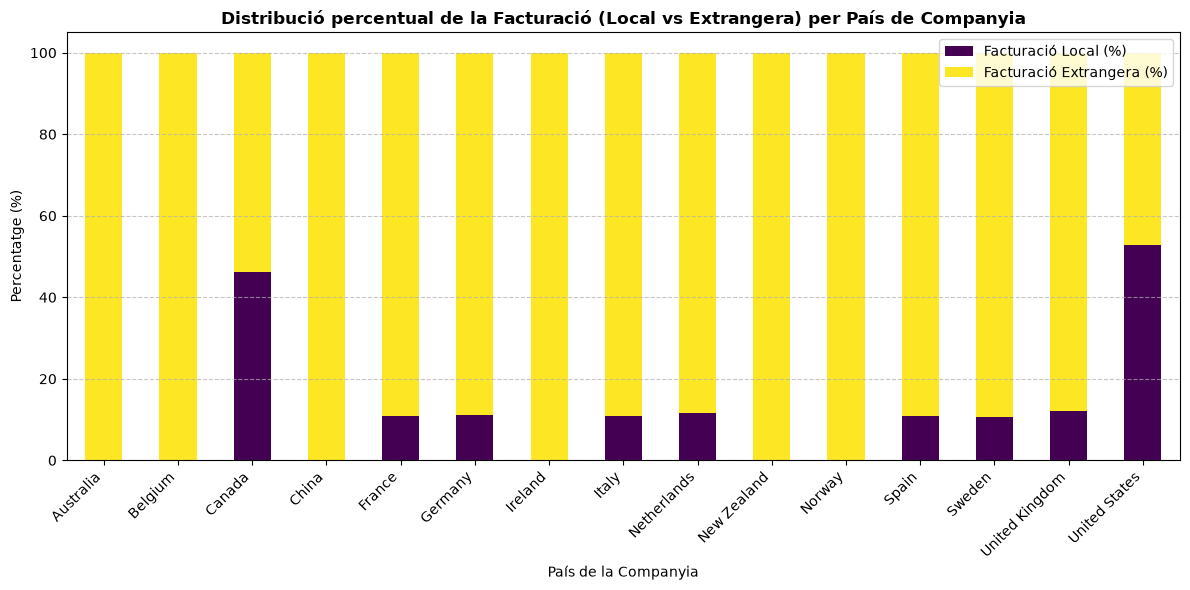

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configurar el gráfico para el Paso 6 (Visualización del fenómeno)
plt.figure(figsize=(12, 6))

# Gráfico de barras apiladas con la facturación local y extranjera por país de compañía
analisis_pais_company.set_index('country_company')[['%_fact_local', '%_fact_estrangeria']].plot(
    kind='bar',
    stacked=True,
    figsize=(12, 6),
    colormap='viridis'
)

plt.title("Distribució percentual de la Facturació (Local vs Extrangera) per País de Companyia", fontsize=12, fontweight='bold')
plt.xlabel("País de la Companyia", fontsize=10)
plt.ylabel("Percentatge (%)", fontsize=10)
plt.legend(["Facturació Local (%)", "Facturació Extrangera (%)"], loc="upper right")
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**¿En qué países valdría la pena abrir más compañías locales?**
Valdría la pena enfocar la expansión en países grandes o mercados clave donde la barra amarilla (facturación extranjera) es del 100% o muy alta (como Reino Unido, Alemania, Francia, Italia o incluso Australia), lo que indica que hay un volumen masivo de clientes consumiendo desde fuera al no haber suficiente estructura local.

**¿Hay países con demanda pero poca oferta local?**
Sí, destaca claramente el caso de países como Australia, Bélgica, China, Irlanda, Nueva Zelanda y Noruega, donde el 100% de la facturación proviene de transacciones extranjeras. Esto demuestra que existe una demanda activa de usuarios en esos territorios, pero la oferta local es nula.

**¿El negocio depende demasiado de compañías de un solo país?**
El grueso de la estructura de empresas con peso real y ventas locales se concentra fuertemente en Norteamérica (EE. UU. y Canadá), mientras que en el resto del mundo operan casi como "fantasmas".

**¿Abrir compañías locales reduciría fricción o mejoraría conversión?**
Sí, de forma muy clara. Al abrir compañías locales en los países donde actualmente operan al 100% de forma internacional, se eliminan las barreras del coste del comercio internacional, lo que aumentaría los beneficios y la confianza del consumidor en el producto local, así como la tasa de conversión.